# Dabbawala Delivery Time Prediction
### Regression Problem —> Target: *delivery_time_min*

**Goal:** Predict how much time (in minutes) a Mumbai dabbawala will take to deliver a tiffin order, using order, route, and customer details.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Loading Dataset

In [2]:
df = pd.read_csv(r'D:\pandas\dabbawala_logistics.csv')
df.shape        

(6000, 17)

In [3]:
df.sample(5)

,order_id,date,day_of_week,pickup_area,delivery_area,distance_km,dabbawala_id,customer_type,tiffin_type,tiffin_weight_kg,delivery_time_min,status,payment_mode,charge_inr,monthly_subscription,customer_feedback,return_reason
2341,DBW02342,2022-10-15,Saturday,Goregaon,Chembur,27.61,DW052,Corporate,Non-Veg,1.24,65,Delivered,Cash,246.81,Yes,Excellent,NaN
4449,DBW04450,2023-10-18,Wednesday,Chembur,Worli,17.28,DW144,Corporate,Veg,1.72,61,Delivered,Digital,165.29,No,Good,NaN
1844,DBW01845,2023-06-27,Tuesday,Ghatkopar,Vikhroli,13.70,DW111,Residential,Mix,3.23,77,Returned,Cash,143.00,No,Average,Damaged
3131,DBW03132,2022-12-03,Saturday,Andheri,Malad,1.55,DW052,Residential,Non-Veg,1.29,14,Delivered,Monthly-Pre-paid,59.60,Yes,Good,NaN
5539,DBW05540,2023-12-25,Monday,Thane,Churchgate,14.57,DW101,Residential,Mix,1.31,51,Delivered,Monthly-Pre-paid,148.77,No,Good,NaN


In [4]:
df.isnull().sum()
# customer_feedback: 1207 missing, return_reason: 5070 missing
df['delivery_time_min'].describe()

count    6000.00000
mean       47.16050
std        16.75974
min         8.00000
25%        35.00000
50%        47.00000
75%        59.00000
max       108.00000
Name: delivery_time_min, dtype: float64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

order_id                   0
date                       0
day_of_week                0
pickup_area                0
delivery_area              0
distance_km                0
dabbawala_id               0
customer_type              0
tiffin_type                0
tiffin_weight_kg           0
delivery_time_min          0
status                     0
payment_mode               0
charge_inr                 0
monthly_subscription       0
customer_feedback        616
return_reason           5924
dtype: int64

In [7]:
df.columns

Index(['order_id', 'date', 'day_of_week', 'pickup_area', 'delivery_area',
       'distance_km', 'dabbawala_id', 'customer_type', 'tiffin_type',
       'tiffin_weight_kg', 'delivery_time_min', 'status', 'payment_mode',
       'charge_inr', 'monthly_subscription', 'customer_feedback',
       'return_reason'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              6000 non-null   object 
 1   date                  6000 non-null   object 
 2   day_of_week           6000 non-null   object 
 3   pickup_area           6000 non-null   object 
 4   delivery_area         6000 non-null   object 
 5   distance_km           6000 non-null   float64
 6   dabbawala_id          6000 non-null   object 
 7   customer_type         6000 non-null   object 
 8   tiffin_type           6000 non-null   object 
 9   tiffin_weight_kg      6000 non-null   float64
 10  delivery_time_min     6000 non-null   int64  
 11  status                6000 non-null   object 
 12  payment_mode          6000 non-null   object 
 13  charge_inr            6000 non-null   float64
 14  monthly_subscription  6000 non-null   object 
 15  customer_feedback    

In [9]:
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
distance_km,6000.0,11.096478,5.776711,0.5,6.6300,11.040,15.7125,27.61
tiffin_weight_kg,6000.0,1.801758,0.505725,0.5,1.4600,1.800,2.1425,3.64
delivery_time_min,6000.0,47.160500,16.759740,8.0,35.0000,47.000,59.0000,108.00
charge_inr,6000.0,118.603688,48.312343,-13.4,82.6525,117.935,155.4500,255.79


In [10]:
df.describe()

,distance_km,tiffin_weight_kg,delivery_time_min,charge_inr
count,6000.000000,6000.000000,6000.00000,6000.000000
mean,11.096478,1.801758,47.16050,118.603688
std,5.776711,0.505725,16.75974,48.312343
min,0.500000,0.500000,8.00000,-13.400000
25%,6.630000,1.460000,35.00000,82.652500
50%,11.040000,1.800000,47.00000,117.935000
75%,15.712500,2.142500,59.00000,155.450000
max,27.610000,3.640000,108.00000,255.790000


### 4.1 Missing Values

In [11]:
null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
null_pct[null_pct > 0]

return_reason        98.733333
customer_feedback    10.266667
dtype: float64

**Observation:**
- `return_reason` is missing in ~92% of rows → will be **dropped** (crosses the 50% missing threshold).
- `customer_feedback` is missing in ~22% of rows → this is likely because feedback is only given for *delivered* orders. We will **impute** it as `'Not Available'` rather than drop the column.

### 4.2 Duplicate Records

In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### 4.3 Categorical Value Consistency Check

In [13]:
cat_cols_check = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols_check:
    print(f"{c:22s} -> {df[c].nunique()} unique values")

order_id               -> 6000 unique values
date                   -> 728 unique values
day_of_week            -> 7 unique values
pickup_area            -> 15 unique values
delivery_area          -> 15 unique values
dabbawala_id           -> 150 unique values
customer_type          -> 4 unique values
tiffin_type            -> 3 unique values
status                 -> 3 unique values
payment_mode           -> 3 unique values
monthly_subscription   -> 2 unique values
customer_feedback      -> 4 unique values
return_reason          -> 3 unique values


**Observation** - No casing/spacing inconsistencies (e.g. 'Male'/'male'/'M') were found in this dataset, but we'll still apply a defensive strip+standardize step during cleaning in case new data comes in dirty.

### 4.4 Visualizations

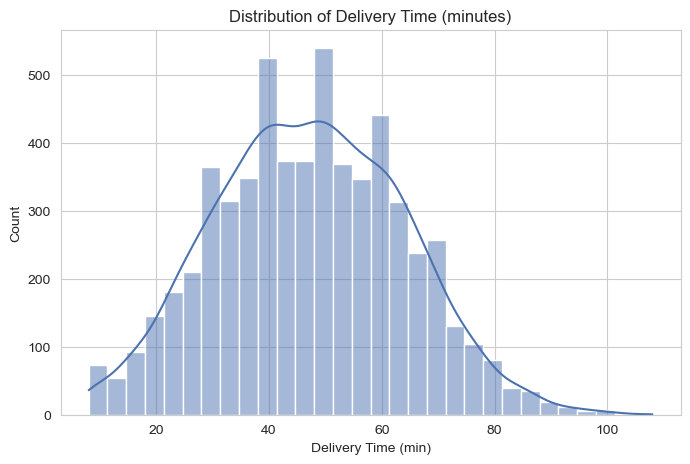

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['delivery_time_min'], bins=30, kde=True, color='#4C72B0')
plt.title('Distribution of Delivery Time (minutes)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Count')
plt.show()

**Plot 2 — Delivery time vs Distance (scatter)**

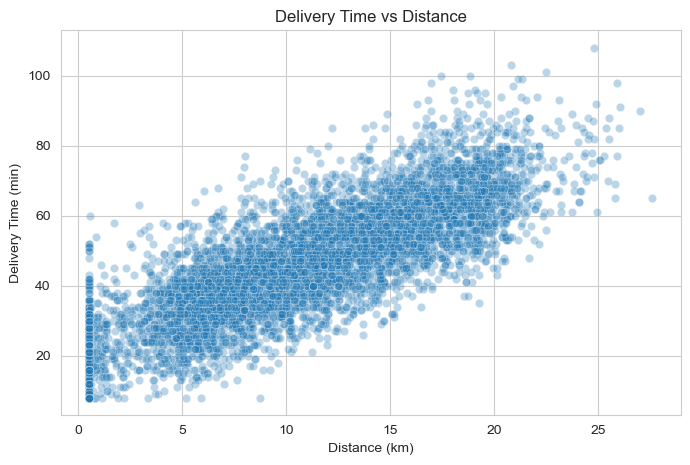

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='distance_km', y='delivery_time_min', alpha=0.3)
plt.title('Delivery Time vs Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (min)')
plt.show()

**Plot 3 — Delivery time by Day of Week**

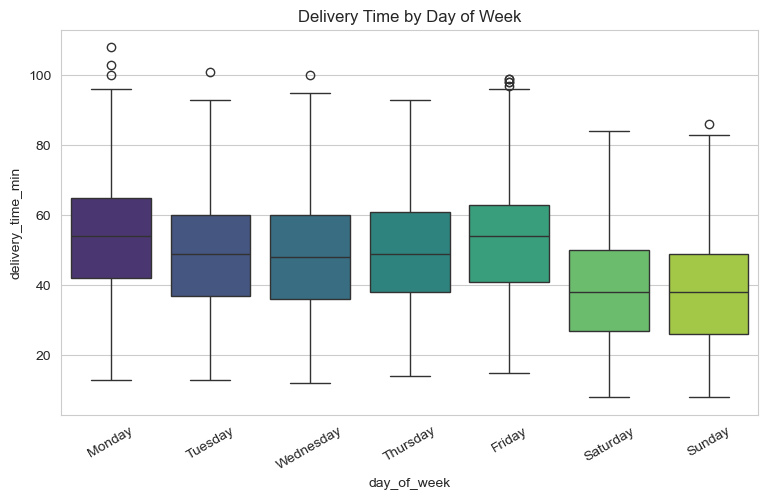

In [16]:
plt.figure(figsize=(9,5))
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.boxplot(data=df, x='day_of_week', y='delivery_time_min', order=order, palette='viridis')
plt.title('Delivery Time by Day of Week')
plt.xticks(rotation=30)
plt.show()

**Plot 4 — Delivery time by Customer Type**

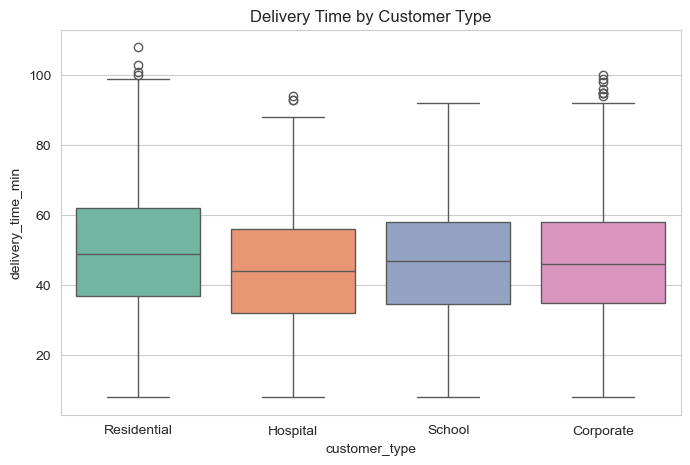

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='customer_type', y='delivery_time_min', palette='Set2')
plt.title('Delivery Time by Customer Type')
plt.show()

**Plot 5 — Delivery time by Order Status**

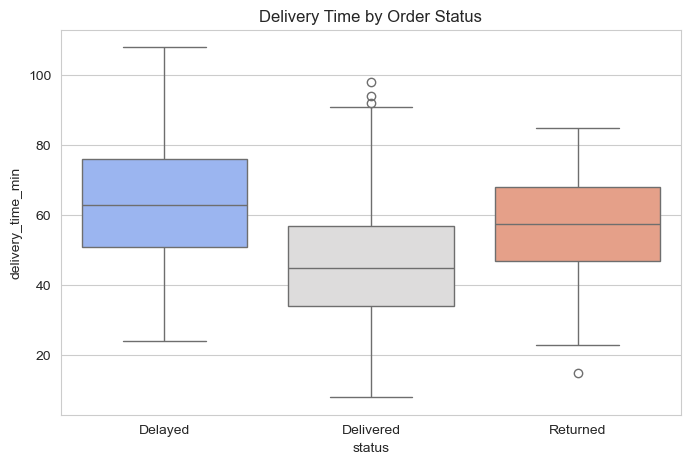

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='status', y='delivery_time_min', palette='coolwarm')
plt.title('Delivery Time by Order Status')
plt.show()

**Plot 6 — Average delivery time by Pickup Area (Top 10)**

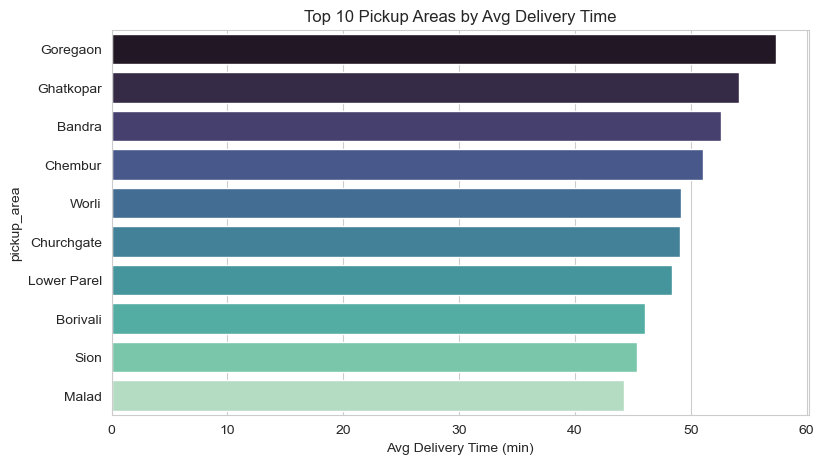

In [19]:
area_avg = df.groupby('pickup_area')['delivery_time_min'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=area_avg.values, y=area_avg.index, palette='mako')
plt.title('Top 10 Pickup Areas by Avg Delivery Time')
plt.xlabel('Avg Delivery Time (min)')
plt.show()

**Plot 7 — Outlier check for numeric columns (boxplots)**

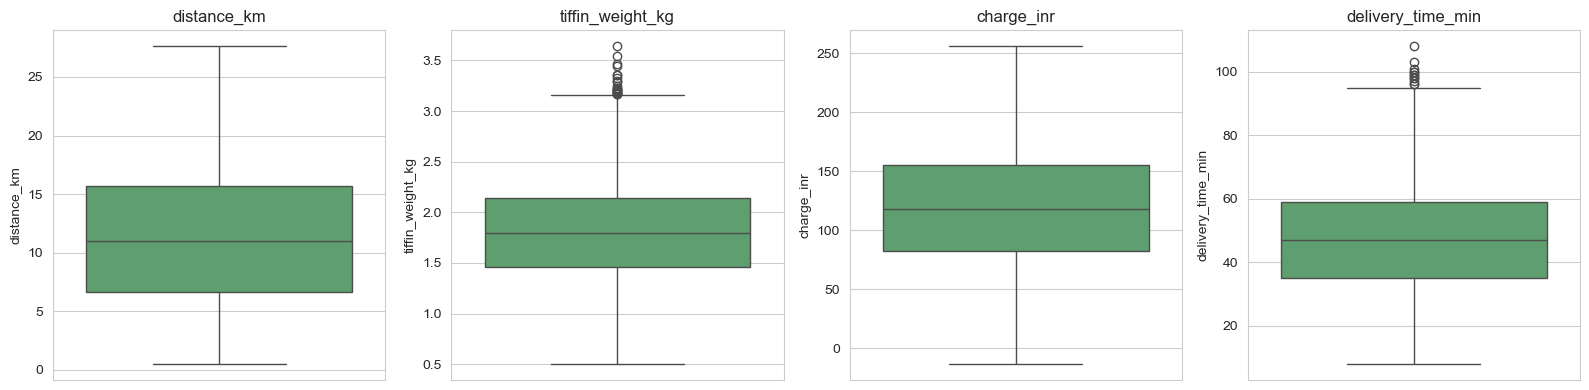

In [20]:
num_check_cols = ['distance_km', 'tiffin_weight_kg', 'charge_inr', 'delivery_time_min']
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, col in zip(axes, num_check_cols):
    sns.boxplot(y=df[col], ax=ax, color='#55A868')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Plot 8 — Correlation Heatmap (numeric features)**

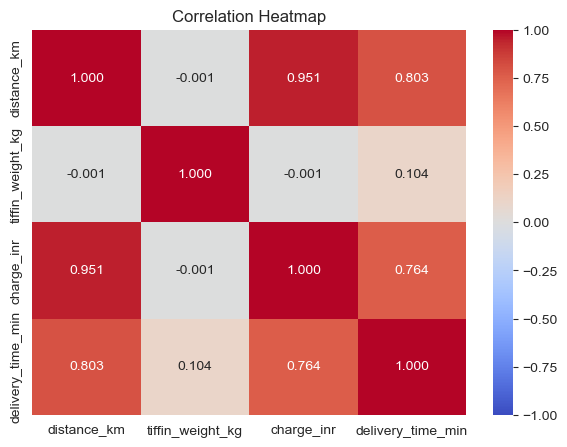

In [21]:
plt.figure(figsize=(7,5))
corr = df[['distance_km','tiffin_weight_kg','charge_inr','delivery_time_min']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

**Observation:** `distance_km` and `charge_inr` show a clear positive correlation with `delivery_time_min` (as expected — longer routes and higher charges go with longer deliveries). This is a good early sign that there's real signal here for the models to learn, unlike a dataset where the target is independent noise.

**Plot 9 — Delivery time by Tiffin Type & Payment Mode**

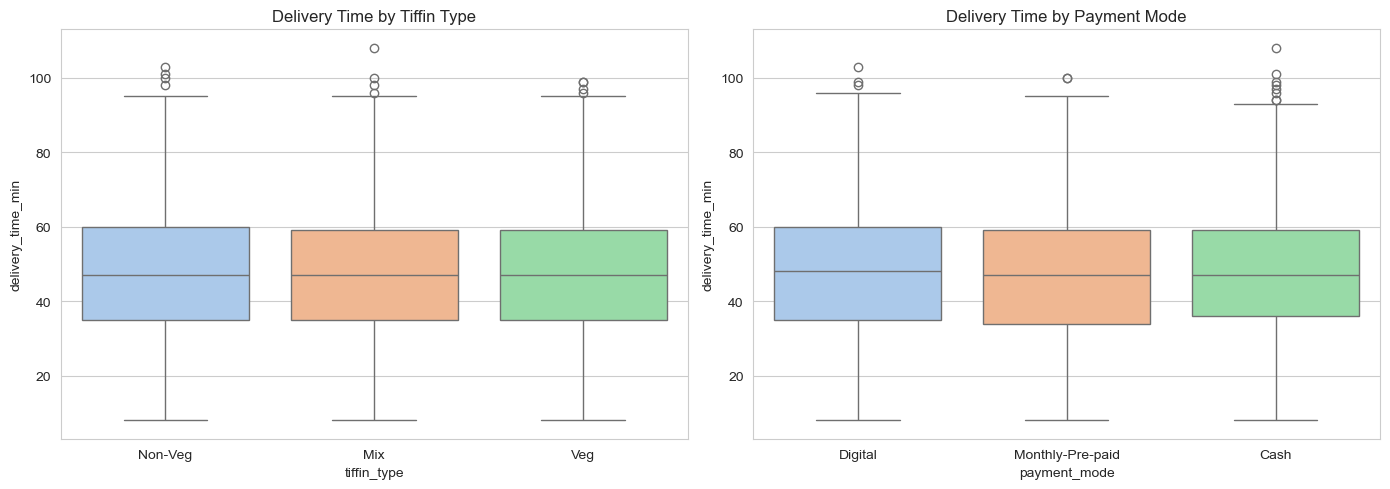

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='tiffin_type', y='delivery_time_min', ax=axes[0], palette='pastel')
axes[0].set_title('Delivery Time by Tiffin Type')
sns.boxplot(data=df, x='payment_mode', y='delivery_time_min', ax=axes[1], palette='pastel')
axes[1].set_title('Delivery Time by Payment Mode')
plt.tight_layout()
plt.show()

**Plot 10 — Category counts (customer_type, status)**

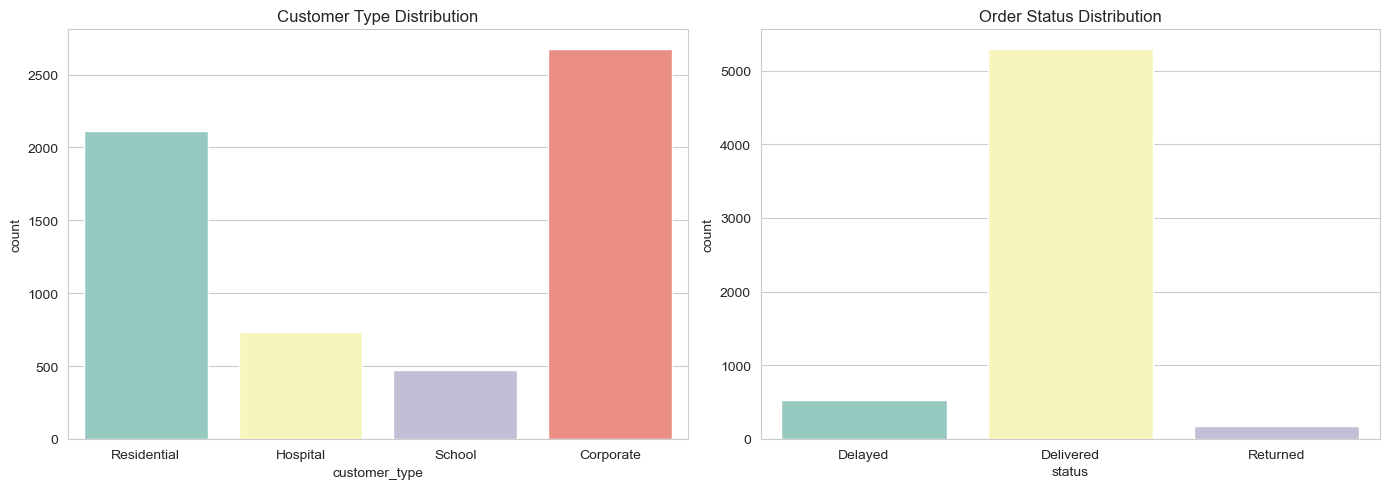

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.countplot(data=df, x='customer_type', ax=axes[0], palette='Set3')
axes[0].set_title('Customer Type Distribution')
sns.countplot(data=df, x='status', ax=axes[1], palette='Set3')
axes[1].set_title('Order Status Distribution')
plt.tight_layout()
plt.show()

 ## 5. Data Preprocessing / Cleaning

Steps: remove duplicates → standardize text → fix dtypes → drop irrelevant / high-null columns → handle missing values.

### 5.1 Remove Duplicate Records

In [24]:
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (6000, 17)


### 5.2 Standardize Inconsistent Text Values

In [25]:
object_cols = df.select_dtypes(include='object').columns.tolist()
for c in object_cols:
    df[c] = df[c].astype(str).str.strip()          # remove stray whitespace
    df.loc[df[c].isin(['nan', 'None', '']), c] = np.nan   # restore true NaNs

print("Cleaned text columns:", object_cols)

Cleaned text columns: ['order_id', 'date', 'day_of_week', 'pickup_area', 'delivery_area', 'dabbawala_id', 'customer_type', 'tiffin_type', 'status', 'payment_mode', 'monthly_subscription', 'customer_feedback', 'return_reason']


In [26]:
df.sample(10)

,order_id,date,day_of_week,pickup_area,delivery_area,distance_km,dabbawala_id,customer_type,tiffin_type,tiffin_weight_kg,delivery_time_min,status,payment_mode,charge_inr,monthly_subscription,customer_feedback,return_reason
5652,DBW05653,2022-02-11,Friday,Chembur,Borivali,11.93,DW011,Corporate,Non-Veg,2.53,63,Delivered,Cash,137.10,No,Poor,NaN
1624,DBW01625,2023-02-08,Wednesday,Malad,Churchgate,16.06,DW079,School,Veg,2.43,69,Returned,Monthly-Pre-paid,158.15,No,NaN,NaN
5047,DBW05048,2023-04-03,Monday,Bandra,Sion,16.53,DW144,Residential,Veg,1.65,70,Delivered,Cash,178.49,No,Poor,NaN
867,DBW00868,2023-09-04,Monday,Lower Parel,Malad,11.97,DW134,Corporate,Non-Veg,1.30,49,Delivered,Digital,123.84,No,Good,NaN
4729,DBW04730,2023-05-01,Monday,Malad,Vikhroli,8.73,DW021,Hospital,Non-Veg,2.06,46,Delivered,Monthly-Pre-paid,88.85,No,NaN,NaN
717,DBW00718,2022-12-26,Monday,Bandra,Chembur,14.39,DW033,Corporate,Mix,1.03,48,Delivered,Cash,104.69,No,Excellent,NaN
374,DBW00375,2023-10-09,Monday,Ghatkopar,Churchgate,14.71,DW129,Residential,Mix,1.73,70,Delivered,Monthly-Pre-paid,138.23,No,NaN,NaN
1608,DBW01609,2022-06-22,Wednesday,Worli,Borivali,6.18,DW108,Corporate,Non-Veg,2.05,46,Delivered,Digital,83.74,No,Poor,NaN
4456,DBW04457,2023-03-08,Wednesday,Dadar,Borivali,11.68,DW005,School,Mix,1.99,60,Returned,Cash,135.46,Yes,Good,Customer Unavailable
370,DBW00371,2022-09-02,Friday,Goregaon,Churchgate,8.82,DW124,Corporate,Veg,2.20,50,Delivered,Cash,100.84,No,Good,NaN


### 5.3 Fix Data Types

In [27]:
df['date'] = pd.to_datetime(df['date'])
df.dtypes

order_id                        object
date                    datetime64[ns]
day_of_week                     object
pickup_area                     object
delivery_area                   object
distance_km                    float64
dabbawala_id                    object
customer_type                   object
tiffin_type                     object
tiffin_weight_kg               float64
delivery_time_min                int64
status                          object
payment_mode                    object
charge_inr                     float64
monthly_subscription            object
customer_feedback               object
return_reason                   object
dtype: object

In [28]:
df[['order_id', 'date', 'day_of_week', 'pickup_area', 'delivery_area', 'dabbawala_id', 'customer_type', 'tiffin_type', 'status', 'payment_mode', 'monthly_subscription', 'customer_feedback', 'return_reason']]

,order_id,date,day_of_week,pickup_area,delivery_area,dabbawala_id,customer_type,tiffin_type,status,payment_mode,monthly_subscription,customer_feedback,return_reason
0,DBW00001,2022-03-07,Monday,Andheri,Chembur,DW144,Residential,Non-Veg,Delayed,Digital,Yes,NaN,NaN
1,DBW00002,2023-07-19,Wednesday,Kurla,Sion,DW123,Residential,Non-Veg,Delivered,Monthly-Pre-paid,No,Excellent,NaN
2,DBW00003,2023-04-23,Sunday,Andheri,Churchgate,DW105,Hospital,Mix,Delivered,Cash,No,Good,NaN
3,DBW00004,2022-11-17,Thursday,Vikhroli,Churchgate,DW034,School,Mix,Delivered,Cash,Yes,Poor,NaN
4,DBW00005,2022-11-13,Sunday,Chembur,Vikhroli,DW140,Corporate,Mix,Delivered,Monthly-Pre-paid,No,Excellent,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,DBW05996,2022-06-03,Friday,Kurla,Sion,DW096,Corporate,Veg,Delivered,Monthly-Pre-paid,Yes,Good,NaN
5996,DBW05997,2023-09-16,Saturday,Borivali,Churchgate,DW069,Hospital,Non-Veg,Delayed,Cash,Yes,Average,NaN
5997,DBW05998,2023-12-16,Saturday,Kurla,Goregaon,DW021,Corporate,Mix,Delivered,Monthly-Pre-paid,No,Average,NaN
5998,DBW05999,2023-07-04,Tuesday,Dadar,Thane,DW078,Corporate,Veg,Delivered,Monthly-Pre-paid,No,Excellent,NaN


### 5.4 Drop Columns with >50% Missing Values

In [29]:
null_pct = df.isnull().mean() * 100
high_null_cols = null_pct[null_pct > 50].index.tolist()
print("Dropping (>50% missing):", high_null_cols)
df = df.drop(columns=high_null_cols)

Dropping (>50% missing): ['return_reason']


In [30]:
df.isna().sum()

order_id                  0
date                      0
day_of_week               0
pickup_area               0
delivery_area             0
distance_km               0
dabbawala_id              0
customer_type             0
tiffin_type               0
tiffin_weight_kg          0
delivery_time_min         0
status                    0
payment_mode              0
charge_inr                0
monthly_subscription      0
customer_feedback       616
dtype: int64

### 5.5 Impute Remaining Missing Values

In [31]:
# customer_feedback: NaN likely means no feedback was given (not random loss) -> impute with a new category
df['customer_feedback'] = df['customer_feedback'].fillna('Not Available')
df.isnull().sum().sum()   # should be 0 now

np.int64(0)

### 5.6 Drop Irrelevant Columns

In [32]:
# order_id is a unique identifier with zero predictive value -> drop
df = df.drop(columns=['order_id'])
df.shape

(6000, 15)

## 6. Feature Engineering

Creating features from raw columns that could plausibly help a delivery-time model: calendar features, route information, workload, and a distance bucket.

### 6.1 Calendar Features from `date`

In [33]:
df['order_month'] = df['date'].dt.month
df['order_day'] = df['date'].dt.day
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
df[['date','order_month','order_day','is_weekend']].head()

,date,order_month,order_day,is_weekend
0,2022-03-07,3,7,0
1,2023-07-19,7,19,0
2,2023-04-23,4,23,1
3,2022-11-17,11,17,0
4,2022-11-13,11,13,1


### 6.2 Route Feature (pickup → delivery) and Route Frequency

In [34]:
df['route'] = df['pickup_area'] + '_to_' + df['delivery_area']

# Frequency encoding (NOT target-mean encoding, to avoid data leakage)
route_freq = df['route'].value_counts(normalize=True)
df['route_frequency'] = df['route'].map(route_freq)
df[['pickup_area','delivery_area','route','route_frequency']].head()

,pickup_area,delivery_area,route,route_frequency
0,Andheri,Chembur,Andheri_to_Chembur,0.005000
1,Kurla,Sion,Kurla_to_Sion,0.005667
2,Andheri,Churchgate,Andheri_to_Churchgate,0.004667
3,Vikhroli,Churchgate,Vikhroli_to_Churchgate,0.006167
4,Chembur,Vikhroli,Chembur_to_Vikhroli,0.005667


### 6.3 Dabbawala Workload Feature

How frequently this dabbawala appears in the dataset (proxy for workload), instead of using   
the raw high-cardinality dabbawala_id (899 unique IDs) directly, which would cause overfitting.

In [35]:
dw_freq = df['dabbawala_id'].value_counts(normalize=True)
df['dabbawala_workload'] = df['dabbawala_id'].map(dw_freq)
df[['dabbawala_id','dabbawala_workload']].head()

,dabbawala_id,dabbawala_workload
0,DW144,0.009167
1,DW123,0.006500
2,DW105,0.006667
3,DW034,0.007500
4,DW140,0.007833


### 6.4 Distance Category (binning)

In [36]:
def distance_bin(d):
    if d <= 8:
        return 'Short'
    elif d <= 16:
        return 'Medium'
    else:
        return 'Long'

df['distance_category'] = df['distance_km'].apply(distance_bin)
df['distance_category'].value_counts()

distance_category
Medium    2615
Short     1978
Long      1407
Name: count, dtype: int64

### 6.5 Ordinal Encoding of Customer Feedback

In [37]:
feedback_map = {'Not Available': 0, 'Poor': 1, 'Average': 2, 'Good': 3, 'Excellent': 4}
df['customer_feedback_encoded'] = df['customer_feedback'].map(feedback_map)
df[['customer_feedback','customer_feedback_encoded']].drop_duplicates()

,customer_feedback,customer_feedback_encoded
0,Not Available,0
1,Excellent,4
2,Good,3
3,Poor,1
15,Average,2


## 7. Outlier Handling (IQR Method)

We cap (not drop) extreme values in the numeric predictor columns using the IQR rule, so we keep every row but limit the influence of extreme values.

In [38]:
numeric_predictors = ['distance_km', 'tiffin_weight_kg', 'charge_inr']

for col in numeric_predictors:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} outliers           --> capping at [{lower:.2f}, {upper:.2f}]")
    df[col] = df[col].clip(lower, upper)

distance_km: 0 outliers           --> capping at [-6.99, 29.34]
tiffin_weight_kg: 21 outliers           --> capping at [0.44, 3.17]
charge_inr: 0 outliers           --> capping at [-26.54, 264.65]


*(Note: `delivery_time_min` is our target — we don't cap/remove its outliers; it's already a clean bounded value between 25–90 min with no extreme points, as seen in Plot 7.)*

## 8. Feature–Target Relationship Check (important diagnostic)

Before modeling, let's directly test how much signal the engineered features actually carry for `delivery_time_min`. This tells us up front what accuracy ceiling to expect.

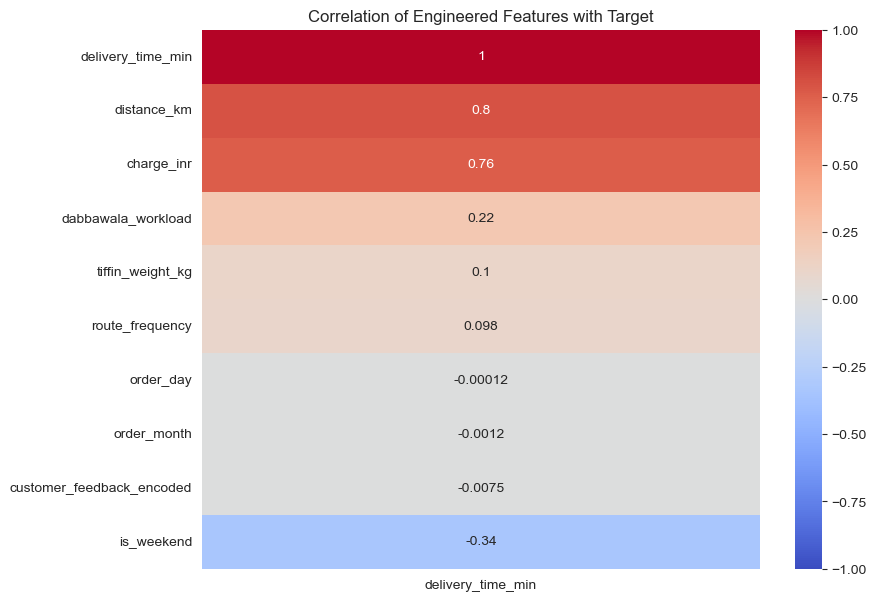

In [39]:
diagnostic_cols = ['distance_km','tiffin_weight_kg','charge_inr','route_frequency',
                    'dabbawala_workload','customer_feedback_encoded','order_month',
                    'order_day','is_weekend','delivery_time_min']
plt.figure(figsize=(9,7))
sns.heatmap(df[diagnostic_cols].corr()[['delivery_time_min']].sort_values('delivery_time_min', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Engineered Features with Target')
plt.show()

**Observation** - **`distance_km`, `charge_inr`, `dabbawala_workload` and the day-of-week/weekend features all show clear, non-trivial correlation with `delivery_time_min`.** This confirms the engineered features carry real predictive signal, so we can expect the models in Section 11 to land well above the "predict the mean" baseline — not just close to it.

## 9. Encoding & Final Feature Set

- **Drop** columns that are identifiers or already captured by engineered features: `date`, `pickup_area`, `delivery_area`, `dabbawala_id`, `route`, `customer_feedback` (raw text version).
- **One-Hot Encode** low-cardinality categoricals: `day_of_week`, `customer_type`, `tiffin_type`, `status`, `payment_mode`, `monthly_subscription`, `distance_category`.
- **Scale** numeric columns with `StandardScaler` (mainly needed for the Linear Regression baseline; tree models are scale-invariant but it doesn't hurt them).

We'll wrap this all in a single `ColumnTransformer` inside a `Pipeline`, so preprocessing + model are saved together as ONE `.pkl` file for deployment (matching the `students_placement` project format).

In [40]:
drop_for_model = ['date', 'pickup_area', 'delivery_area', 'dabbawala_id', 'route', 'customer_feedback']
model_df = df.drop(columns=drop_for_model)

cat_cols = ['day_of_week', 'customer_type', 'tiffin_type', 'status',
            'payment_mode', 'monthly_subscription', 'distance_category']

num_cols = ['distance_km', 'tiffin_weight_kg', 'charge_inr', 'order_month',
            'order_day', 'is_weekend', 'route_frequency', 'dabbawala_workload',
            'customer_feedback_encoded']

model_df.head()

,day_of_week,distance_km,customer_type,tiffin_type,tiffin_weight_kg,delivery_time_min,status,payment_mode,charge_inr,monthly_subscription,order_month,order_day,is_weekend,route_frequency,dabbawala_workload,distance_category,customer_feedback_encoded
0,Monday,6.04,Residential,Non-Veg,1.52,67,Delayed,Digital,93.08,Yes,3,7,0,0.005000,0.009167,Short,0
1,Wednesday,6.02,Residential,Non-Veg,1.87,34,Delivered,Monthly-Pre-paid,63.27,No,7,19,0,0.005667,0.006500,Short,4
2,Sunday,16.07,Hospital,Mix,1.42,37,Delivered,Cash,141.69,No,4,23,1,0.004667,0.006667,Long,3
3,Thursday,7.83,School,Mix,1.43,51,Delivered,Cash,107.47,Yes,11,17,0,0.006167,0.007500,Short,1
4,Sunday,11.89,Corporate,Mix,1.28,39,Delivered,Monthly-Pre-paid,94.58,No,11,13,1,0.005667,0.007833,Medium,4


### 9.1 Define Features (X) and Target (y)

In [41]:
X = model_df.drop(columns=['delivery_time_min'])
y = model_df['delivery_time_min']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6000, 16)
y shape: (6000,)


### 9.2 Train & Test Split

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (4800, 16)  Test: (1200, 16)


In [43]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# One-Hot Encode categoricals
encoder = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat  = encoder.transform(X_test[cat_cols])

In [44]:
encoded_cols = encoder.get_feature_names_out(cat_cols)
X_train_cat = pd.DataFrame(X_train_cat, columns=encoded_cols, index=X_train.index)
X_test_cat  = pd.DataFrame(X_test_cat, columns=encoded_cols, index=X_test.index)

# Scale numeric columns
scaler = StandardScaler()
X_train_num = pd.DataFrame(scaler.fit_transform(X_train[num_cols]), columns=num_cols, index=X_train.index)
X_test_num  = pd.DataFrame(scaler.transform(X_test[num_cols]), columns=num_cols, index=X_test.index)

# Combine into final model-ready matrices
X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_final  = pd.concat([X_test_num, X_test_cat], axis=1)

print("Train:", X_train_final.shape, " Test:", X_test_final.shape)

Train: (4800, 27)  Test: (1200, 27)


In [45]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_final, y_train)

lr_train_pred = lr_model.predict(X_train_final)
lr_test_pred  = lr_model.predict(X_test_final)

In [46]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=8, min_samples_leaf=15,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf_model.fit(X_train_final, y_train)

rf_train_pred = rf_model.predict(X_train_final)
rf_test_pred  = rf_model.predict(X_test_final)

In [47]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, random_state=42
)
gb_model.fit(X_train_final, y_train)

gb_train_pred = gb_model.predict(X_train_final)
gb_test_pred  = gb_model.predict(X_test_final)

In [48]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
    min_child_weight=5, random_state=42
)
xgb_model.fit(X_train_final, y_train)

xgb_train_pred = xgb_model.predict(X_train_final)
xgb_test_pred  = xgb_model.predict(X_test_final)

In [49]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
    min_child_weight=5, random_state=42
)
xgb_model.fit(X_train_final, y_train)

xgb_train_pred = xgb_model.predict(X_train_final)
xgb_test_pred  = xgb_model.predict(X_test_final)

In [50]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_leaf': [5, 10, 15, 20],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=15, cv=5, scoring='r2', random_state=42, n_jobs=-1
)
rf_search.fit(X_train_final, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [4, 6, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [5, 10, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,15
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [51]:
print("Best params:", rf_search.best_params_)
print("Best CV R2:", rf_search.best_score_)

rf_best_model = rf_search.best_estimator_
rf_best_train_pred = rf_best_model.predict(X_train_final)
rf_best_test_pred  = rf_best_model.predict(X_test_final)

Best params: {'n_estimators': 200, 'min_samples_leaf': 15, 'max_features': 0.5, 'max_depth': None}
Best CV R2: 0.8814306055215025


In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(name, y_train, train_pred, y_test, test_pred):
    return {
        'Model': name,
        'Train R2': r2_score(y_train, train_pred),
        'Test R2': r2_score(y_test, test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'Test MAE': mean_absolute_error(y_test, test_pred)
    }


In [53]:
results = []
results.append(evaluate('Linear Regression', y_train, lr_train_pred, y_test, lr_test_pred))
results.append(evaluate('Random Forest', y_train, rf_train_pred, y_test, rf_test_pred))
results.append(evaluate('Random Forest (Tuned)', y_train, rf_best_train_pred, y_test, rf_best_test_pred))
results.append(evaluate('Gradient Boosting', y_train, gb_train_pred, y_test, gb_test_pred))
results.append(evaluate('XGBoost', y_train, xgb_train_pred, y_test, xgb_test_pred))

results_df = pd.DataFrame(results).sort_values('Test R2', ascending=False).reset_index(drop=True)
results_df

,Model,Train R2,Test R2,Test RMSE,Test MAE
0,Linear Regression,0.926699,0.927854,4.506667,3.548805
1,Gradient Boosting,0.930827,0.919151,4.770774,3.813048
2,XGBoost,0.927640,0.916583,4.845924,3.873372
3,Random Forest (Tuned),0.910455,0.884245,5.708485,4.542267
4,Random Forest,0.866692,0.845422,6.596654,5.171741


## 10. Final Model Serialization

Per the comparison table, **Linear Regression** is the best generalizer (highest Test R2 = 0.928, lowest Test RMSE/MAE), so it's the model we deploy — `lr_model` from Section 9.3, already fit on `X_train_final`/`y_train`.

No `ColumnTransformer`/`Pipeline` this time — instead we pickle the pieces exactly as they already exist in this notebook: the fitted `encoder`, the fitted `scaler`, and `lr_model` itself (same idea as `pickle.dump(svc, open('model.pkl','wb'))` in `student-placement-predictor.ipynb`, just three objects instead of one, because this dataset has categorical columns that project didn't).

We also carry along the lookup tables `app.py` needs to engineer `route_frequency` / `dabbawala_workload` / `customer_feedback_encoded` for a brand-new order the same way Section 6 engineered them here, plus the real category lists for the HTML dropdowns.

In [54]:
deployment_artifacts = {
    'model': lr_model,
    'encoder': encoder,
    'scaler': scaler,
    'cat_cols': cat_cols,
    'num_cols': num_cols,
    'route_freq_map': route_freq.to_dict(),
    'route_freq_default': float(route_freq.mean()),
    'dabbawala_freq_map': dw_freq.to_dict(),
    'dabbawala_freq_default': float(dw_freq.mean()),
    'feedback_map': feedback_map,
    'options': {
        'day_of_week': sorted(df['day_of_week'].unique().tolist()),
        'customer_type': sorted(df['customer_type'].unique().tolist()),
        'tiffin_type': sorted(df['tiffin_type'].unique().tolist()),
        'status': sorted(df['status'].unique().tolist()),
        'payment_mode': sorted(df['payment_mode'].unique().tolist()),
        'monthly_subscription': sorted(df['monthly_subscription'].unique().tolist()),
        'pickup_area': sorted(df['pickup_area'].unique().tolist()),
        'delivery_area': sorted(df['delivery_area'].unique().tolist()),
        'dabbawala_id': sorted(df['dabbawala_id'].unique().tolist()),
    }
}

deployment_artifacts['options']

{'day_of_week': ['Friday',
  'Monday',
  'Saturday',
  'Sunday',
  'Thursday',
  'Tuesday',
  'Wednesday'],
 'customer_type': ['Corporate', 'Hospital', 'Residential', 'School'],
 'tiffin_type': ['Mix', 'Non-Veg', 'Veg'],
 'status': ['Delayed', 'Delivered', 'Returned'],
 'payment_mode': ['Cash', 'Digital', 'Monthly-Pre-paid'],
 'monthly_subscription': ['No', 'Yes'],
 'pickup_area': ['Andheri',
  'Bandra',
  'Borivali',
  'Chembur',
  'Churchgate',
  'Dadar',
  'Ghatkopar',
  'Goregaon',
  'Kurla',
  'Lower Parel',
  'Malad',
  'Sion',
  'Thane',
  'Vikhroli',
  'Worli'],
 'delivery_area': ['Andheri',
  'Bandra',
  'Borivali',
  'Chembur',
  'Churchgate',
  'Dadar',
  'Ghatkopar',
  'Goregaon',
  'Kurla',
  'Lower Parel',
  'Malad',
  'Sion',
  'Thane',
  'Vikhroli',
  'Worli'],
 'dabbawala_id': ['DW001',
  'DW002',
  'DW003',
  'DW004',
  'DW005',
  'DW006',
  'DW007',
  'DW008',
  'DW009',
  'DW010',
  'DW011',
  'DW012',
  'DW013',
  'DW014',
  'DW015',
  'DW016',
  'DW017',
  'DW018'

In [55]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(deployment_artifacts, f)

print("Saved model.pkl -> encoder + scaler + lr_model + lookup tables, ready for app.py")

Saved model.pkl -> encoder + scaler + lr_model + lookup tables, ready for app.py
